<a href="https://colab.research.google.com/github/hiteshbalaji147-rgb/machine-learning-projects/blob/main/15_3_credit_card_fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**15.3. Project 3 - Credit Card Fraud Detection**

**Dataset:** `creditcard.csv`

Highly Imbalanced Dataset

**Dataset reference:** https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

**1. Setup**

In [1]:
# install the required libraries
%pip install -q numpy pandas matplotlib seaborn scikit-learn

In [2]:
# importing the dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    average_precision_score,
)

In [3]:
# configurations
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")

RANDOM_STATE = 42

**2. Load data**

In [4]:
df = pd.read_csv("creditcard.csv")

**3. Exploratory Data Analysis (EDA)**

In [5]:
df.shape

(162557, 31)

In [6]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.000,-1.360,-0.073,2.536,1.378,-0.338,0.462,0.240,0.099,0.364,0.091,-0.552,-0.618,-0.991,-0.311,1.468,-0.470,0.208,0.026,0.404,0.251,-0.018,0.278,-0.110,0.067,0.129,-0.189,0.134,-0.021,149.620,0.000
1,0.000,1.192,0.266,0.166,0.448,0.060,-0.082,-0.079,0.085,-0.255,-0.167,1.613,1.065,0.489,-0.144,0.636,0.464,-0.115,-0.183,-0.146,-0.069,-0.226,-0.639,0.101,-0.340,0.167,0.126,-0.009,0.015,2.690,0.000
2,1.000,-1.358,-1.340,1.773,0.380,-0.503,1.800,0.791,0.248,-1.515,0.208,0.625,0.066,0.717,-0.166,2.346,-2.890,1.110,-0.121,-2.262,0.525,0.248,0.772,0.909,-0.689,-0.328,-0.139,-0.055,-0.060,378.660,0.000
3,1.000,-0.966,-0.185,1.793,-0.863,-0.010,1.247,0.238,0.377,-1.387,-0.055,-0.226,0.178,0.508,-0.288,-0.631,-1.060,-0.684,1.966,-1.233,-0.208,-0.108,0.005,-0.190,-1.176,0.647,-0.222,0.063,0.061,123.500,0.000
4,2.000,-1.158,0.878,1.549,0.403,-0.407,0.096,0.593,-0.271,0.818,0.753,-0.823,0.538,1.346,-1.120,0.175,-0.451,-0.237,-0.038,0.803,0.409,-0.009,0.798,-0.137,0.141,-0.206,0.502,0.219,0.215,69.990,0.000


Class:
- 0 -> non-fraud
- 1 -> fraud

In [7]:
# basic overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162557 entries, 0 to 162556
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    162557 non-null  float64
 1   V1      162557 non-null  float64
 2   V2      162557 non-null  float64
 3   V3      162557 non-null  float64
 4   V4      162557 non-null  float64
 5   V5      162557 non-null  float64
 6   V6      162557 non-null  float64
 7   V7      162557 non-null  float64
 8   V8      162557 non-null  float64
 9   V9      162557 non-null  float64
 10  V10     162557 non-null  float64
 11  V11     162557 non-null  float64
 12  V12     162557 non-null  float64
 13  V13     162557 non-null  float64
 14  V14     162557 non-null  float64
 15  V15     162557 non-null  float64
 16  V16     162557 non-null  float64
 17  V17     162557 non-null  float64
 18  V18     162557 non-null  float64
 19  V19     162557 non-null  float64
 20  V20     162557 non-null  float64
 21  V21     16

In [8]:
# missing values
df.isna().sum().sort_values(ascending=False)

,0
Amount,1
V28,1
Class,1
V3,0
Time,0
V1,0
V2,0
V7,0
V8,0
V9,0


In [9]:
# quick checks for encoded missing values
for col in df.columns:
    print(df[col].value_counts().head(10))

Time
64947.000    26
68780.000    25
3767.000     21
3770.000     20
19912.000    19
3750.000     19
3766.000     17
73885.000    17
39897.000    17
3749.000     17
Name: count, dtype: int64
V1
1.246     77
2.056     76
1.302     60
1.333     45
1.018     40
1.335     39
-0.303    36
1.315     36
0.899     28
1.311     27
Name: count, dtype: int64
V2
0.167     77
-0.327    76
-0.607    60
0.389     45
1.037     40
0.331     39
0.447     36
-0.034    36
0.034     28
0.075     27
Name: count, dtype: int64
V3
0.488     77
-2.752    76
-0.682    60
-2.166    45
-1.690    40
-2.058    39
-0.496    36
-1.090    36
-0.083    28
-1.293    27
Name: count, dtype: int64
V4
0.635     77
-0.842    76
-1.905    60
-0.307    45
1.315     40
-0.346    39
-3.215    36
-0.557    36
1.256     28
-0.483    27
Name: count, dtype: int64
V5
-0.563    77
2.463     76
1.327     60
2.641     45
1.698     40
2.583     39
2.705     36
2.030     36
0.554     28
2.139     27
Name: count, dtype: int64
V6
-1.011    7

In [10]:
# duplicates
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()
print("Number of duplicate rows:", num_duplicates)

# (optional) drop duplicates if present
# df = df.drop_duplicates()
# print("Shape after dropping duplicates:", df.shape)


Number of duplicate rows: 616


In [11]:
# target distribution
print(df["Class"].value_counts())
print("-"*50)
print(df["Class"].value_counts(normalize=True) * 100)

Class
0.000    162200
1.000       356
Name: count, dtype: int64
--------------------------------------------------
Class
0.000   99.781
1.000    0.219
Name: proportion, dtype: float64


**NOTE: Data is Highly Imbalanced**

In [12]:
# imbalance ratio
n_fraud = (df["Class"] == 1).sum()
n_nonfraud = (df["Class"] == 0).sum()
print("\nImbalance ratio (non-fraud : fraud) =", round(n_nonfraud / max(n_fraud, 1), 2))


Imbalance ratio (non-fraud : fraud) = 455.62


**Inference: 1 fraud transaction for 577 non-fraud transactions**

In [13]:
# descriptive stats for key columns
df[["Time", "Amount"]].describe()

,Time,Amount
count,162557.000,162556.000
mean,58171.885,86.985
std,25278.368,244.369
min,0.000,0.000
25%,40328.000,5.370
50%,58863.000,21.300
75%,76367.000,76.130
max,115211.000,19656.530


In [14]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,162557.000,162557.000,162557.000,162557.000,162557.000,162557.000,162557.000,162557.000,162557.000,162557.000,162557.000,162557.000,162557.000,162557.000,162557.000,162557.000,162557.000,162557.000,162557.000,162557.000,162557.000,162557.000,162557.000,162557.000,162557.000,162557.000,162557.000,162557.000,162556.000,162556.000,162556.000
mean,58171.885,-0.198,0.052,0.551,0.135,-0.201,0.064,-0.092,0.041,0.021,-0.038,0.215,-0.107,0.074,0.097,0.151,-0.012,0.048,-0.053,-0.023,0.034,-0.034,-0.096,-0.025,0.010,0.104,0.014,0.002,0.003,86.985,0.002
std,25278.368,1.845,1.612,1.362,1.364,1.334,1.292,1.208,1.235,1.159,1.097,1.049,1.161,1.057,0.980,0.954,0.882,0.921,0.834,0.812,0.723,0.745,0.658,0.584,0.597,0.457,0.492,0.392,0.309,244.369,0.047
min,0.000,-56.408,-72.716,-33.681,-5.520,-42.148,-26.161,-43.557,-73.217,-13.434,-24.588,-4.050,-18.684,-5.792,-19.214,-4.499,-14.130,-25.163,-9.499,-7.214,-22.839,-34.830,-10.933,-44.808,-2.837,-10.295,-2.605,-22.566,-11.711,0.000,0.000
25%,40328.000,-1.001,-0.528,0.018,-0.722,-0.846,-0.683,-0.590,-0.155,-0.661,-0.521,-0.543,-0.522,-0.624,-0.324,-0.430,-0.472,-0.409,-0.523,-0.503,-0.181,-0.232,-0.549,-0.171,-0.329,-0.178,-0.331,-0.064,-0.019,5.370,0.000
50%,58863.000,-0.221,0.119,0.665,0.143,-0.246,-0.196,-0.039,0.063,-0.082,-0.115,0.136,0.111,0.039,0.101,0.267,0.062,-0.012,-0.054,-0.027,-0.034,-0.058,-0.076,-0.039,0.062,0.147,-0.060,0.010,0.022,21.300,0.000
75%,76367.000,1.176,0.811,1.320,0.957,0.341,0.453,0.449,0.358,0.650,0.396,1.026,0.621,0.758,0.536,0.848,0.526,0.441,0.427,0.466,0.157,0.120,0.344,0.094,0.414,0.405,0.277,0.090,0.078,76.130,0.000
max,115211.000,2.439,22.058,9.383,16.875,34.802,22.529,36.677,20.007,15.595,23.745,12.019,7.848,4.569,10.527,5.785,6.099,9.254,5.041,5.228,39.421,27.203,10.503,19.003,4.023,7.520,3.517,12.152,33.848,19656.530,1.000


**Data Visualization**

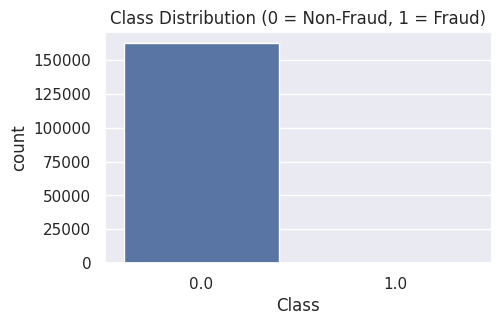

In [15]:
# visualize class imbalance
plt.figure(figsize=(5, 3))
sns.countplot(x="Class", data=df)
plt.title("Class Distribution (0 = Non-Fraud, 1 = Fraud)")
plt.show()

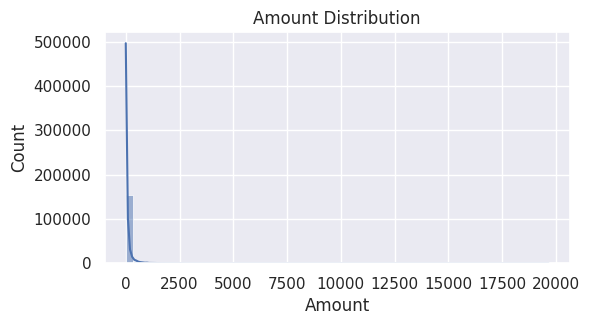

In [16]:
# Amount distribution (raw)
plt.figure(figsize=(6, 3))
sns.histplot(df["Amount"], bins=60, kde=True)
plt.title("Amount Distribution")
plt.show()

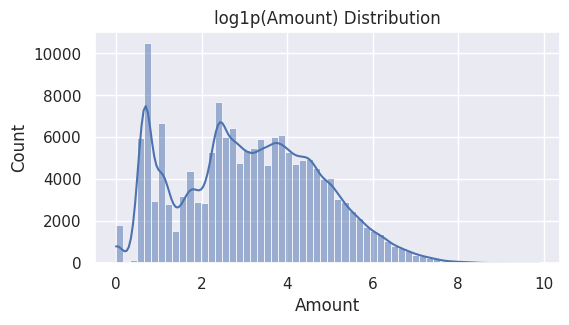

In [17]:
# Amount distribution (raw + log1p)
plt.figure(figsize=(6, 3))
sns.histplot(np.log1p(df["Amount"]), bins=60, kde=True)
plt.title("log1p(Amount) Distribution")
plt.show()

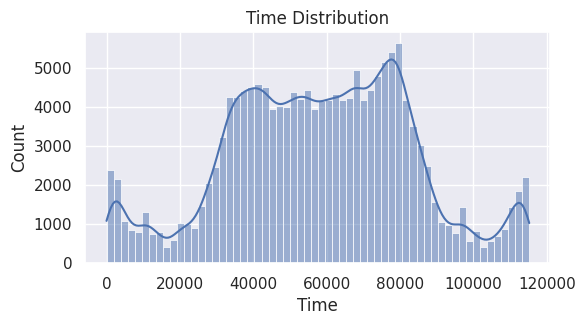

In [18]:
# Time distribution
plt.figure(figsize=(6, 3))
sns.histplot(df["Time"], bins=60, kde=True)
plt.title("Time Distribution")
plt.show()

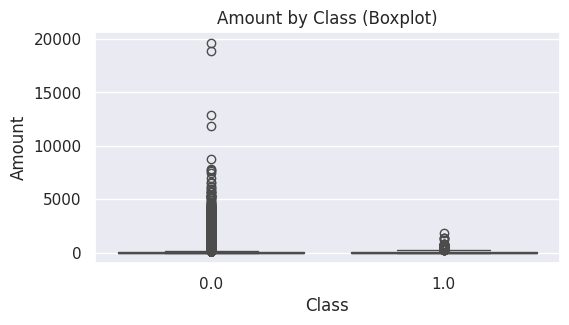

In [19]:
# Amount by class (helps intuition)
plt.figure(figsize=(6, 3))
sns.boxplot(x="Class", y="Amount", data=df)
plt.title("Amount by Class (Boxplot)")
plt.show()

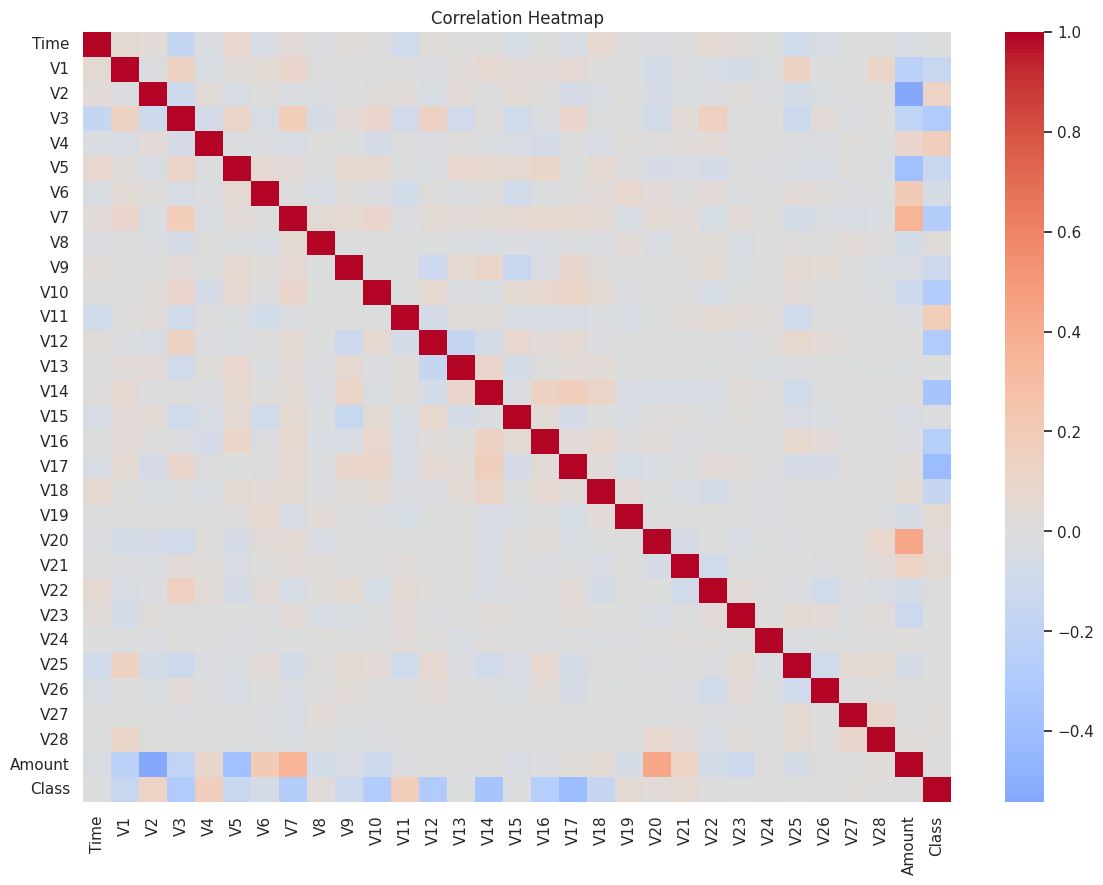

In [20]:
# correlation heatmap (can be heavy but useful)
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

**There are no highly correlated columns (probably beacuase of PCA applied columns)**

In [21]:
# correlation with target (top signals)
corr_target = df.corr(numeric_only=True)["Class"].sort_values(ascending=False)
corr_target.head(5), corr_target.tail(5)

(Class   1.000
 V11     0.185
 V4      0.164
 V2      0.127
 V21     0.050
 Name: Class, dtype: float64,
 V10   -0.283
 V12   -0.289
 V3    -0.294
 V14   -0.352
 V17   -0.419
 Name: Class, dtype: float64)

**4. Data Preprocessing**

In [22]:
# Add log1p(Amount) for stability
df["Amount_log1p"] = np.log1p(df["Amount"])

In [23]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class', 'Amount_log1p'],
      dtype='object')

In [27]:
# Drop any row with NaN values from the entire DataFrame to ensure a completely clean dataset for X and y.
df_cleaned = df.dropna().reset_index(drop=True)

# separate features and target from the thoroughly cleaned DataFrame
X = df_cleaned.drop(columns=["Class", "Amount"])   # removing AMount as we have Amount_log1p
y = df_cleaned["Class"]

# Add explicit checks for NaNs in X and y to confirm cleanliness
print(f"Number of NaNs in X after cleaning: {X.isnull().sum().sum()}")
print(f"Number of NaNs in y after cleaning: {y.isnull().sum()}")

Number of NaNs in X after cleaning: 0
Number of NaNs in y after cleaning: 0


In [28]:
# train test split

# Ensure y contains only finite values and is of integer type for stratification
if not np.isfinite(y).all():
    raise ValueError("y contains non-finite values even after cleaning.")

y_int = y.astype(int) # Convert to int for robust stratification

# Confirm unique values in y_int for stratification
print(f"Unique values in y for stratification: {y_int.unique()}")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_int, # Use the integer-typed target variable for stratification
    test_size=0.2,
    stratify=y_int,
    random_state=RANDOM_STATE
)

Unique values in y for stratification: [0 1]


In [29]:
print("Dataset Shape:", X.shape)
print("Training Data Shape:", X_train.shape)
print("Test Data Shape:", X_test.shape)

Dataset Shape: (162556, 30)
Training Data Shape: (130044, 30)
Test Data Shape: (32512, 30)


**5. Baseline Model**

In [30]:
base_pipeline = Pipeline(
    [
        ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]
)

In [31]:
# train the model
base_pipeline.fit(X_train, y_train)

Pipeline(steps=[('model', DecisionTreeClassifier(random_state=42))])

In [32]:
y_base_train_pred = base_pipeline.predict(X_train)
y_base_test_pred = base_pipeline.predict(X_test)

In [33]:
base_train_acc = round(accuracy_score(y_train, y_base_train_pred)*100, 2)
base_test_acc = round(accuracy_score(y_test, y_base_test_pred)*100, 2)

In [34]:
print("Baseline Train Accuracy:", base_train_acc)
print("Baseline Test Accuracy:", base_test_acc)

Baseline Train Accuracy: 100.0
Baseline Test Accuracy: 99.89


In [35]:
print("Train - Classification Report")
print(classification_report(y_train, y_base_train_pred))

Train - Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    129759
           1       1.00      1.00      1.00       285

    accuracy                           1.00    130044
   macro avg       1.00      1.00      1.00    130044
weighted avg       1.00      1.00      1.00    130044



In [36]:
print("Test - Classification Report")
print(classification_report(y_test, y_base_test_pred))

Test - Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     32441
           1       0.74      0.75      0.74        71

    accuracy                           1.00     32512
   macro avg       0.87      0.87      0.87     32512
weighted avg       1.00      1.00      1.00     32512



**Note: Accuracy score is not reliable because of class imbalance**

In [37]:
# average precision score (or) pr-auc - training data
y_train_prob = base_pipeline.predict_proba(X_train)[:, 1]
print("Training Average Precision Score:", average_precision_score(y_train, y_train_prob))

Training Average Precision Score: 1.0


In [38]:
# average precision score (or) pr-auc - test data
y_test_prob = base_pipeline.predict_proba(X_test)[:, 1]
print("Test Average Precision Score:", average_precision_score(y_test, y_test_prob))

Test Average Precision Score: 0.5500450345335355


**6. Model & optimization**

In [39]:
k = 5
cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

In [40]:
models = {
    "dt_balanced": Pipeline(
        [
            ("model", DecisionTreeClassifier(
                random_state=RANDOM_STATE,
                class_weight="balanced"
            ))
        ]
    ),
    "hgb_balanced": Pipeline(
        [
            ("model", HistGradientBoostingClassifier(
                random_state=RANDOM_STATE,
                class_weight="balanced"
            ))
        ]
    ),
    "rf_balanced": Pipeline(
        [
            ("model", RandomForestClassifier(
                random_state=RANDOM_STATE,
                class_weight="balanced_subsample"
            ))
        ]
    )
}

In [42]:
for name, m in models.items():

    pr_auc_scores = []

    for tr_idx, te_idx, in cv.split(X_train, y_train):
        X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
        y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]

        m.fit(X_tr, y_tr)
        pred_prob = m.predict_proba(X_te)[:, 1]

        pr_auc_scores.append(average_precision_score(y_te, pred_prob))

    print("Model name:", name)
    print("PR-AUC values:", pr_auc_scores)
    print("CV PR-AUC mean:", round(float(np.mean(pr_auc_scores)), 4))

# cross validation is a more reliable metric

Model name: dt_balanced
PR-AUC values: [np.float64(0.5632561492792061), np.float64(0.5903309386893005), np.float64(0.5404646860276592), np.float64(0.6633301986944754), np.float64(0.5957184460215915)]
CV PR-AUC mean: 0.5906
Model name: hgb_balanced
PR-AUC values: [np.float64(0.8042857934614683), np.float64(0.7501901289903016), np.float64(0.7206511798479139), np.float64(0.8553144137541377), np.float64(0.799928004397066)]
CV PR-AUC mean: 0.7861
Model name: rf_balanced
PR-AUC values: [np.float64(0.8937593629633019), np.float64(0.829724581493561), np.float64(0.8606890749155405), np.float64(0.8821999521564718), np.float64(0.8631254202010169)]
CV PR-AUC mean: 0.8659


**Best Model as per model selection process:** Random Forest Classifier

**Hyper parameter tuning for Random Forest Classifier**

In [43]:
rfc_pipeline = Pipeline([
    ("model", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ))
])

In [44]:
# hyperparameter tuining - Random Forest Classifier
param_dist = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_leaf": [1, 5, 10, 20],
    "model__max_features": ["sqrt", "log2", 0.5]
}

In [45]:
# random search
random_search = RandomizedSearchCV(
    estimator=rfc_pipeline,
    param_distributions=param_dist,
    n_iter=10,
    scoring="average_precision",  # PR-AUC
    cv=cv,
    verbose=True
)

In [68]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


KeyboardInterrupt: 

In [47]:
print("Best CV PR-AUC:", round(random_search.best_score_, 4))
print("Best params:", random_search.best_params_)

AttributeError: 'RandomizedSearchCV' object has no attribute 'best_score_'

**7. Re-train with best parameters**

In [48]:
best_rfc = Pipeline(
    [
        ("model", RandomForestClassifier(
            n_estimators=500,
            min_samples_leaf=1,
            max_features="log2",
            max_depth=30,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced_subsample"
        ))
    ]
)

In [49]:
# train best rfc
best_rfc.fit(X_train, y_train)

Pipeline(steps=[('model',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        max_depth=30, max_features='log2',
                                        n_estimators=500, n_jobs=-1,
                                        random_state=42))])

**8. Model Evaluation**

In [50]:
# training data prediction
y_train_pred = best_rfc.predict(X_train)

In [52]:
train_acc = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {round(train_acc*100, 2)} %")

Training Accuracy: 100.0 %


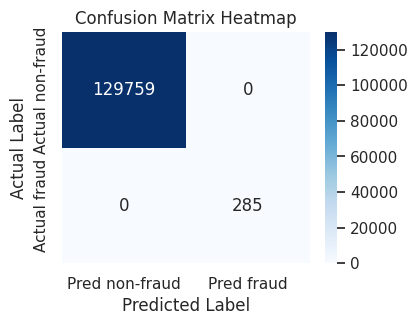

In [53]:
# confusion matrix
cm = confusion_matrix(y_train, y_train_pred)

plt.figure(figsize=(4,3))
# heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred non-fraud", "Pred fraud"],
    yticklabels=["Actual non-fraud", "Actual fraud"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [54]:
print("Training Classification report")
print(classification_report(y_train, y_train_pred))

Training Classification report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    129759
           1       1.00      1.00      1.00       285

    accuracy                           1.00    130044
   macro avg       1.00      1.00      1.00    130044
weighted avg       1.00      1.00      1.00    130044



In [55]:
train_proba = best_rfc.predict_proba(X_train)[:, 1]
print("Train PR-AUC:", round(average_precision_score(y_train, train_proba), 4))

Train PR-AUC: 1.0


In [56]:
# test data prediction
y_test_pred = best_rfc.predict(X_test)

In [57]:
test_acc = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {round(test_acc*100, 2)} %")

Test Accuracy: 99.93 %


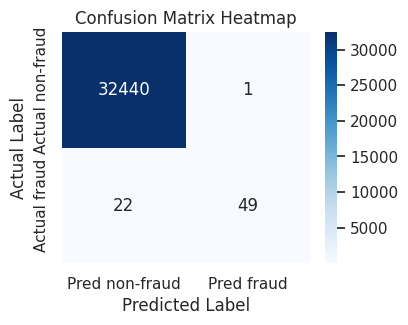

In [58]:
# confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(4,3))
# heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred non-fraud", "Pred fraud"],
    yticklabels=["Actual non-fraud", "Actual fraud"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [59]:
print("Test Classification report")
print(classification_report(y_test, y_test_pred))

Test Classification report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     32441
           1       0.98      0.69      0.81        71

    accuracy                           1.00     32512
   macro avg       0.99      0.85      0.90     32512
weighted avg       1.00      1.00      1.00     32512



In [60]:
test_proba = best_rfc.predict_proba(X_test)[:, 1]
print("Test PR-AUC:", round(average_precision_score(y_test, test_proba), 4))

Test PR-AUC: 0.8569


**9. Build a predictive system**

In [61]:
def predict_class(input_features):
    input_df = pd.DataFrame(
        [input_features],
        columns=X_train.columns
    )
    # get prediction from trained model
    prediction = best_rfc.predict(input_df)
    print("Model prediction:", prediction)
    if prediction[0] == 1:
        print("Fraud Transaction detected ❌")
    else:
        print("Non-Fraud Transaction ✅")

In [62]:
X_test.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount_log1p
9082,12734.000,-1.286,-0.485,1.985,-1.614,0.802,-0.846,-0.026,-0.044,-0.213,0.077,2.489,-3.049,0.668,1.500,-0.953,1.031,0.808,-1.406,0.001,0.442,-0.334,-1.019,0.138,-0.139,0.139,-0.761,0.029,-0.105,3.548
46802,42934.000,-1.200,-0.966,0.995,-2.491,-0.557,-0.098,-1.132,0.515,-2.119,0.580,-1.507,-1.057,1.018,-0.458,0.448,0.220,0.130,0.244,-1.140,-0.404,0.035,0.194,-0.327,-0.934,0.183,-0.186,-0.149,-0.149,3.689
30942,36147.000,1.466,-0.356,-0.660,-1.042,0.037,-0.395,-0.095,-0.230,-1.433,0.833,0.538,0.036,0.895,0.114,-0.263,1.234,-0.304,-0.804,1.356,0.179,0.180,0.430,-0.339,-0.777,0.936,-0.033,-0.032,-0.017,3.258
79960,58267.000,1.215,0.205,0.632,0.709,-0.674,-1.182,0.066,-0.215,0.060,-0.064,0.033,0.342,0.004,0.312,1.037,0.221,-0.289,-0.615,-0.244,-0.097,-0.232,-0.711,0.170,0.700,0.161,0.074,-0.032,0.024,2.638
111729,72343.000,-0.509,0.326,2.258,0.086,-1.267,-0.219,0.147,0.069,0.660,-0.635,-0.738,-0.085,-0.827,-0.470,-0.100,-0.544,0.545,-0.390,1.171,-0.002,-0.098,-0.091,0.057,0.784,-0.690,0.941,-0.013,0.125,4.253


In [63]:
y_test.head()

,Class
9082,0
46802,0
30942,0
79960,0
111729,0


In [64]:
y_test[y_test == 0].head()

,Class
9082,0
46802,0
30942,0
79960,0
111729,0


In [65]:
y_test[y_test == 1].head()

,Class
40525,1
40085,1
150680,1
151807,1
154694,1


In [66]:
test_1 = X_test.loc[263020].tolist()
print(test_1)

KeyError: 263020

In [ ]:
predict_class(test_1)

In [69]:
test_2 = X_test.loc[77348].tolist()
print(test_2)

[57007.0, -1.27124419171437, 2.46267526851135, -2.85139500331783, 2.3244800653478, -1.37224488981369, -0.948195686538643, -3.06523436172054, 1.16692694787211, -2.26877058844813, -4.88114292689057, 2.25514748870463, -4.68638689759229, 0.652374668512965, -6.17428834800643, 0.594379608016446, -4.84969238709652, -6.53652073527011, -3.11909388163881, 1.71549441975915, 0.560478075726644, 0.652941051330455, 0.0819309763507574, -0.221347831198339, -0.523582159233306, 0.224228161862968, 0.756334522703558, 0.632800477330469, 0.250187092757197, 0.009950330853168083]


In [70]:
predict_class(test_2)

Model prediction: [1]
Fraud Transaction detected ❌


In [71]:
# we can tune probability threshold to improve the performance even more